<a href="https://colab.research.google.com/github/maabmusa7/BinX_Tech_Internship_Project_GROUP5/blob/MohammadAbuHamed_LLM-preparation/EDA_Grammar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exploratory Data Analysis — W&I + LOCNESS

The purpose of this exploratory data analysis is to understand the structure and characteristics of the W&I + LOCNESS dataset before preprocessing and fine-tuning.

This dataset contains English learner texts and grammatical corrections, making it useful for teaching the English Tutor LLM how to recognize and correct common learner mistakes.

The analysis focuses on:

- Dataset size and structure.
- Available columns and data types.
- Missing values.
- CEFR level distribution.
- Text length distribution.
- Number of words in learner texts.
- Number of grammatical edits or corrections.
- Examples of learner mistakes and corrections.

In [4]:
from datasets import load_dataset
grammar_correct1=load_dataset("martinsr/wi_locness")

### Dataset Structure

The dataset structure is inspected to identify the available splits and the number of samples in each split.

In [5]:
print(grammar_correct1)

DatasetDict({
    train: Dataset({
        features: ['text', 'edits', 'cefr', 'id'],
        num_rows: 3000
    })
    validation: Dataset({
        features: ['text', 'edits', 'cefr', 'id'],
        num_rows: 350
    })
})


### Dataset Features
The available dataset columns are inspected to understand what information is provided for each learner text.

In [6]:
print(grammar_correct1["train"].column_names)

['text', 'edits', 'cefr', 'id']


### Sample Record

A sample record is displayed to understand how learner text, corrections, CEFR levels, and other information are represented in the dataset.

In [13]:
print(grammar_correct1["train"][0])

{'text': 'My town is a medium size city with eighty thousand inhabitants. It has a high density population because its small territory. Despite of it is an industrial city, there are many shops and department stores.  I recommend visiting the artificial lake in the certer of the city which is surrounded by a park. Pasteries are very common and most of them offer the special dessert from the city. There are a comercial zone along the widest street of the city where you can find all kind of establishments: banks, bars, chemists, cinemas, pet shops, restaurants, fast food restaurants, groceries, travel agencies, supermarkets and others. Most of the shops have sales and offers at least three months of the year: January, June and August. The quality of the products and services are quite good, because there are a huge competition, however I suggest you taking care about some fakes or cheats.', 'edits': {'start': [13, 77, 104, 126, 134, 256, 306, 375, 396, 402, 476, 484, 579, 671, 774, 804, 

### Convert the Dataset to a Pandas DataFrame

The training split is converted into a Pandas DataFrame to simplify exploration and statistical analysis.

In [14]:
df_grammar = grammar_correct1["train"].to_pandas()
df_grammar.head()

,text,edits,cefr,id
0,My town is a medium size city with eighty thou...,"{'start': [13, 77, 104, 126, 134, 256, 306, 37...",A2.i,1-140178
1,Everyone has his own plans. People want to be ...,"{'start': [28, 56, 106, 118, 124, 131, 152, 17...",A2.i,1-181175
2,Now days each family has more then 1 car for e...,"{'start': [0, 30, 50, 75, 79, 86, 131, 178, 20...",A2.ii,1-59315
3,"Furthermore, the biggest group of positive fee...","{'start': [34, 184, 210, 234, 249, 274, 287, 3...",A1.i,1-232774
4,MORE THAN KIP FIT!\n\nDo you know mountain bik...,"{'start': [10, 31, 100, 127, 130, 181, 197, 27...",A2.ii,1-352674


### Dataset Information

The dataset information is inspected to identify column names, data types, and the number of non-null values.

In [19]:
df_grammar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    3000 non-null   object
 1   edits   3000 non-null   object
 2   cefr    3000 non-null   object
 3   id      3000 non-null   object
dtypes: object(4)
memory usage: 93.9+ KB


### CEFR Level Distribution

The distribution of CEFR proficiency levels is analyzed to determine how learner samples are distributed across different English proficiency levels.


In [18]:
df_grammar["cefr"].value_counts(normalize=True)*100

,proportion
cefr,
A2.ii,14.266667
A2.i,11.366667
A1.ii,10.466667
B1.ii,9.666667
B1.i,9.600000
B2.i,8.566667
C1.ii,7.666667
A1.i,7.233333
C1.i,6.966667


### CEFR Level Distribution Visualization

A bar chart is used to visualize the number of learner samples available at each CEFR proficiency level.

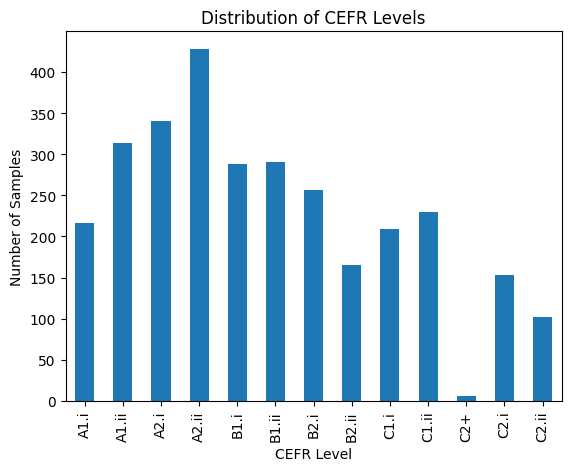

In [20]:
import matplotlib.pyplot as plt

df_grammar["cefr"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("CEFR Level")
plt.ylabel("Number of Samples")
plt.title("Distribution of CEFR Levels")
plt.show()